# House Price Prediction using Multiple Linear Regression

## Model 1: Without Address Feature
## Model 2: With Address Feature

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pylab as pl

In [2]:
data = pd.read_csv("./drive/MyDrive/Colab Notebooks/housePrice.csv")

In [3]:
data.head(5)

,Area,Room,Parking,Warehouse,Elevator,Address,Price,Price(USD)
0,63,1,True,True,True,Shahran,1.850000e+09,61666.67
1,60,1,True,True,True,Shahran,1.850000e+09,61666.67
2,79,2,True,True,True,Pardis,5.500000e+08,18333.33
3,95,2,True,True,True,Shahrake Qods,9.025000e+08,30083.33
4,123,2,True,True,True,Shahrake Gharb,7.000000e+09,233333.33


In [4]:
data.describe()

,Room,Price,Price(USD)
count,3479.000000,3.479000e+03,3.479000e+03
mean,2.079908,5.359023e+09,1.786341e+05
std,0.758275,8.099935e+09,2.699978e+05
min,0.000000,3.600000e+06,1.200000e+02
25%,2.000000,1.418250e+09,4.727500e+04
50%,2.000000,2.900000e+09,9.666667e+04
75%,2.000000,6.000000e+09,2.000000e+05
max,5.000000,9.240000e+10,3.080000e+06


# Data Cleaning



In [11]:
df = data[data["Area"].notna()]

In [13]:
df["Area"] = df["Area"].str.replace(",","")
df["Area"] = pd.to_numeric(df["Area"])

In [14]:
df["Area"].describe()

,Area
count,3.479000e+03
mean,8.744000e+06
std,3.167266e+08
min,3.000000e+01
25%,6.900000e+01
50%,9.000000e+01
75%,1.200000e+02
max,1.616000e+10


In [15]:
df = df[df['Address'].notna()]

In [16]:
df.rename(columns={"Price(USD)":"Price_USD"}, inplace=True)

In [17]:
df["Parking"] = df["Parking"].astype(int)
df["Warehouse"] = df["Warehouse"].astype(int)
df["Elevator"] = df["Elevator"].astype(int)

In [18]:
df = pd.get_dummies(df, columns=["Address"], drop_first=True)

In [22]:
df = df.astype(int)
df = df[df["Area"] < 600]

**Data Frame is cleaned**

In [23]:
df

,Area,Room,Parking,Warehouse,Elevator,Price,Price_USD,Address_Abbasabad,Address_Absard,Address_Abuzar,...,Address_Waterfall,Address_West Ferdows Boulevard,Address_West Pars,Address_Yaftabad,Address_Yakhchiabad,Address_Yousef Abad,Address_Zafar,Address_Zaferanieh,Address_Zargandeh,Address_Zibadasht
0,63,1,1,1,1,1850000000,61666,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,60,1,1,1,1,1850000000,61666,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,79,2,1,1,1,550000000,18333,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,95,2,1,1,1,902500000,30083,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,123,2,1,1,1,7000000000,233333,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3474,86,2,1,1,1,3500000000,116666,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3475,83,2,1,1,1,6800000000,226666,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3476,75,2,0,0,0,365000000,12166,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3477,105,2,1,1,1,5600000000,186666,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## Model 1: Without Address Feature

In [26]:
cdf = df[["Area", "Room", "Parking", "Warehouse", "Elevator", "Price_USD"]]
cdf.head(5)

,Area,Room,Parking,Warehouse,Elevator,Price_USD
0,63,1,1,1,1,61666
1,60,1,1,1,1,61666
2,79,2,1,1,1,18333
3,95,2,1,1,1,30083
4,123,2,1,1,1,233333


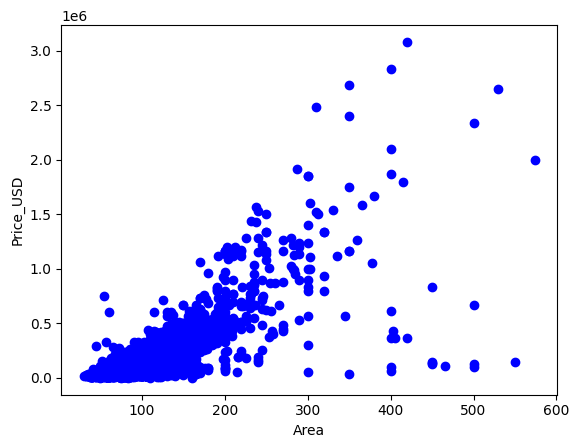

In [27]:
plt.scatter(cdf.Area, cdf.Price_USD, color="blue")
plt.xlabel("Area")
plt.ylabel("Price_USD")
plt.show()

In [28]:
msk = np.random.rand(len(df)) < 0.8
train = cdf[msk]
test= cdf[~msk]

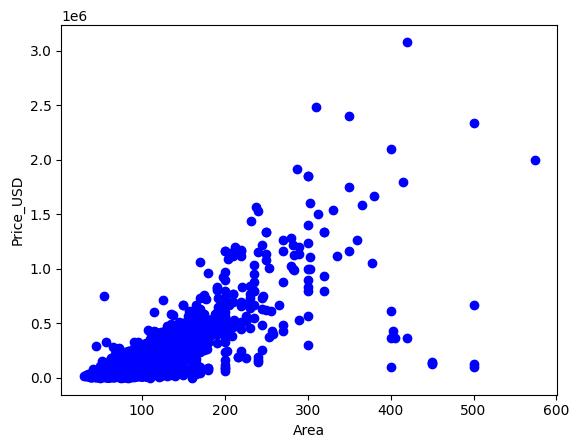

In [29]:
plt.scatter(train.Area, train.Price_USD, color="blue")
plt.xlabel("Area")
plt.ylabel("Price_USD")
plt.show()

In [31]:
from sklearn import linear_model
regr = linear_model.LinearRegression()
x = np.asanyarray(train[["Area", "Room", "Parking", "Warehouse", "Elevator"]])
y = np.asanyarray(train[["Price_USD"]])
regr.fit(x, y)
print("Coefficients: ", regr.coef_)
print("Intercept: ", regr.intercept_)

Coefficients:  [[  3480.20295325 -12811.00404761  -7756.72384903  45053.82736738
   31243.58034994]]
Intercept:  [-222061.01627886]


In [32]:
y_hat = regr.predict(test[["Area", "Room", "Parking", "Warehouse", "Elevator"]])
x = np.asanyarray(test[["Area", "Room", "Parking", "Warehouse", "Elevator"]])
y = np.asanyarray(test[["Price_USD"]])
print("Residual sum of squares: %.2f" % np.mean((y_hat - y) ** 2))
print("Variance score: %.2f" % regr.score(x, y))

Residual sum of squares: 37592047306.32
Variance score: 0.54


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


## Model 2: With Address Feature

In [56]:
new_x = df.drop(["Price", "Price_USD"], axis=1)
new_y = df["Price_USD"]

In [57]:
msk = np.random.rand(len(df)) < 0.8

X_train = new_x[msk]
X_test  = new_x[~msk]

y_train = new_y[msk]
y_test  = new_y[~msk]


In [58]:

regr.fit(X_train, y_train)
print("Coefficients: ", regr.coef_)
print("Intercept: ", regr.intercept_)


Coefficients:  [ 2.73544191e+03 -5.75249501e+04 -4.27078078e+04  5.92414896e+03
 -2.09100434e+04  3.42748323e+03 -1.13525738e+06  2.20535058e+04
 -3.98883104e+04  5.45812022e+04 -2.79235754e+04  9.01465409e+04
  5.62692450e+04  6.83379015e+04  3.57890387e+04 -1.07558711e+05
  3.90633720e+04 -6.39545870e+03  1.26049367e+05 -6.79506280e+04
 -2.57114975e+05  1.25592439e+05 -7.49168165e+04  3.03803504e+04
  5.51567730e+04 -3.99087379e+04  3.18371564e+04  1.63656854e+04
  3.45607718e+04  1.01863407e-10 -3.50044932e+03  3.23661211e+04
 -1.86998196e+05  5.96628524e-10 -2.93580767e+03 -6.08134489e+04
 -8.13172187e+03  2.91038305e-11  3.70786324e+04 -6.91676098e+04
 -4.08689299e+04  3.99396597e+04  2.69489395e+04  1.41621182e+05
 -5.80533668e+03  2.73470371e+04  2.42081611e+03  9.69261298e+02
  3.04968055e+05  1.01787206e+04 -1.75683511e+04 -3.63797881e-10
  3.51594664e+04  5.56096951e+04  1.86804166e+05 -4.52182560e+04
 -4.15156794e+03  1.04139077e+05  4.19923491e+04  9.35611449e+05
 -3.526246

In [59]:
from sklearn.metrics import r2_score

y_hat = regr.predict(X_test)
print("MSE: %.2f" % np.mean((y_hat - y_test) ** 2))
print("R2-score: %.2f" % r2_score(y_test, y_hat))

MSE: 12081987826.53
R2-score: 0.76
